# Swap curves: projection and discounting

Separate the curve forecasting floating coupons from the curve discounting payments.

[Chapter notes](README.md) · [All topics](../../README.md)

## Research design

A floating coupon forecast and the present value of that coupon serve different roles. This chapter asks what changes when a term-index projection curve is distinct from the collateral discount curve.

For a synthetic term index, the projected simple rate is $L=[P^{proj}(t_a)/P^{proj}(t_b)-1]/\tau_{index}$. The coupon amount uses its actual contract accrual and is discounted with $D^{disc}(t_{pay})$. Index value/maturity dates can differ slightly from coupon accrual dates after holiday adjustments.

The fixture supplies OIS par quotes and an illustrative term swap strip 50 basis points above it. QuantLib first bootstraps the OIS discount curve, then builds the term projection curve while discounting its calibration helpers with OIS. The notebook checks both sets of helper residuals and values the same payer swap using dual curves and an OIS-only projection counterfactual. Its fixed coupon remains frozen across that comparison.

The synthetic USD 3M index is not current USD LIBOR. A constant 50-bp input difference is a teaching assumption, not a statement about observed credit or basis premia. The study does not calibrate a full collection of overnight, term, futures, basis and collateral instruments.

Calibration error measures the reproduction of input quotes. The single-curve valuation difference measures a controlled modeling choice. Neither is an observed market pricing error. See [IRS cash flows](../08-interest-rate-swaps/README.md) for the coupon-level reconciliation.

In [1]:
from pathlib import Path
import sys
candidates = [Path.cwd(), *Path.cwd().parents]
ROOT = next(p for p in candidates if (p / 'research' / 'pricing.py').is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import QuantLib as ql
from IPython.display import display
from research.common import RESULTS, check_hashes
from research.pricing import DATE, CAL, valuation_date, curves, fixture
plt.rcParams.update({'figure.dpi':110, 'axes.spines.top':False, 'axes.spines.right':False,
                     'axes.grid':True, 'grid.alpha':.18, 'font.size':11})
# Verify the core fixture, source and saved-output vintage before reading any summary.
check_hashes()
# Every chapter uses explicit illustrative assumptions; never a hidden data download.


## Calculation and independent checks

All inputs below are illustrative. Assertions check the identities discussed in the chapter.

In [2]:
from research.pricing import swap
with valuation_date():
    discount,projection,residuals=curves()
    dual,_,coupon=swap(discount,projection)
    single,_,_=swap(discount,discount,coupon)
    comparison=pd.DataFrame([{'projection':'Separate term curve','fixed_coupon_pct':coupon*100,'payer_swap_PV':dual.NPV()},{'projection':'OIS-only counterfactual','fixed_coupon_pct':coupon*100,'payer_swap_PV':single.NPV()}])
    nodes=[]
    for y in range(1,11):
        date=CAL.advance(DATE,ql.Period(y,ql.Years))
        t=ql.Actual365Fixed().yearFraction(DATE,date)
        nodes.append({'years':y,'discount_zero_pct':-100*np.log(discount.discount(date))/t,'projection_zero_pct':-100*np.log(projection.discount(date))/t})
assert residuals.residual.abs().max()<1e-8
assert abs(comparison.iloc[0].payer_swap_PV)<1e-8
display(comparison.round(6));display(residuals.round(10))

,projection,fixed_coupon_pct,payer_swap_PV
0,Separate term curve,3.959824,-0.00000
1,OIS-only counterfactual,3.959824,-3.09294


,curve,years,quote,implied,residual,pillar
0,discount,1.0,0.0380,0.0380,-0.0,2027-09-15
1,discount,2.0,0.0370,0.0370,0.0,2028-09-15
2,discount,3.0,0.0360,0.0360,0.0,2029-09-17
3,discount,4.0,0.0355,0.0355,0.0,2030-09-16
4,discount,5.0,0.0350,0.0350,0.0,2031-09-15
5,discount,6.0,0.0348,0.0348,0.0,2032-09-15
6,discount,7.0,0.0346,0.0346,0.0,2033-09-15
7,discount,8.0,0.0345,0.0345,0.0,2034-09-15
8,discount,9.0,0.0344,0.0344,0.0,2035-09-17
9,discount,10.0,0.0343,0.0343,0.0,2036-09-15


## Economic relationship

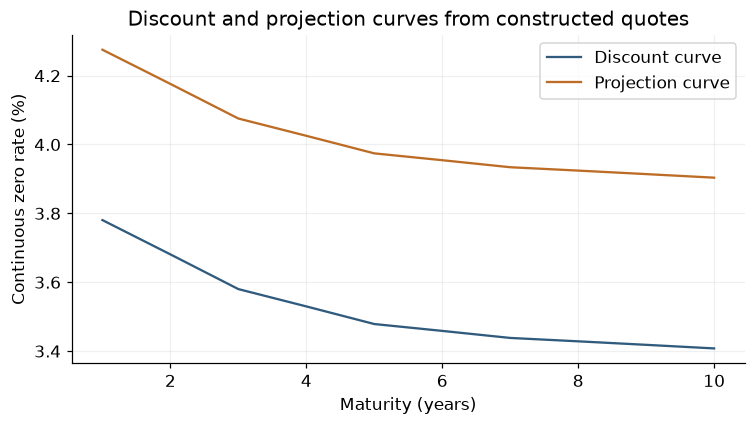

In [3]:
fig,ax=plt.subplots(figsize=(7,4))
pd.DataFrame(nodes).rename(columns={'discount_zero_pct':'Discount curve','projection_zero_pct':'Projection curve'}).plot(x='years',y=['Discount curve','Projection curve'],ax=ax,color=['#315b7d','#bc6c25'])
ax.set(xlabel='Maturity (years)',ylabel='Continuous zero rate (%)',title='Discount and projection curves from constructed quotes')
fig.tight_layout();plt.show()

## Interpretation

Both curves reproduce their own calibration instruments. Substituting the discount curve for term projection changes the swap PV while its contractual fixed coupon remains unchanged.